In [1]:
import numpy as np
import pandas as pd

from utils import validate, package_run_data, package_calib_data, circdist, circmedian
from tqdm import tqdm
import pickle

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import arviz as az
import colorsys

#NP set random seed
np.random.seed(42)

az.style.use("arviz-docgrid")

In [2]:
# Math imports
import math
from functools import partial
from itertools import count
import numpy as np
from scipy.stats import norm, poisson, expon, uniform, binom, beta, halfnorm
import jax.numpy as jnp
import jax.random as jr
from jax import vmap
import optax

from dynamax.hidden_markov_model import GaussianHMM, DiagonalGaussianHMM, LinearRegressionHMM
from dynamax.utils.utils import find_permutation

In [3]:
from jax.lib import xla_bridge
print(xla_bridge.get_backend().platform)

gpu


## Loading data

In [4]:
experiment_orientations = [159, 123, 87, 51, 15]
median_key = {15:0, 51:1, 87:2, 123:3, 159:4}
std_key = {15:0, 51:1, 87:2, 123:3, 159:4}

In [5]:
# Allow negative angles in calibration
c_table, med, std, ctimetable = package_calib_data(do_clip=False)
r_table, (x, y, d, r, e) = package_run_data(med, std, do_clip=False, do_noise_thresh=False)

Loading data: 100%|██████████| 288/288 [00:00<00:00, 301.85it/s]


## Formatting data for models

In [6]:
xaxis = np.arange(-250, 750, 1) * (1000/120)
start_idx, end_idx = np.searchsorted(xaxis, -500), np.searchsorted(xaxis, 1500)
(start_idx, end_idx)

(191, 430)

In [7]:
# our frmes of intrest are only
er = e[:, :, :, :, start_idx:end_idx].reshape(-1, 239)

# ds
ds = d[:, :, :, :, start_idx:end_idx].reshape(-1, 239)

er[np.isnan(er)] = 90
ds[np.isnan(ds)] = 0

er.shape, np.isnan(er).any(), ds.shape, np.isnan(ds).any()

((34560, 239), False, (34560, 239), False)

In [8]:
ds.max(), ds.min(), er.max(), er.min()

(1.0, 0.0, 179.99928775789328, 0.0)

In [9]:
# min max scale err
er = er / 180

train_emissions = jnp.array(np.stack([ds, er], axis=-1))
train_emissions.shape

(34560, 239, 2)

## GLOBAL MODEL

### Subset Cross val for optimal states

In [10]:
crossval_subset = np.random.choice(np.arange(0, len(train_emissions)), 50, replace=False)
crossval_emissions = train_emissions[crossval_subset]

In [11]:
num_train_batches = crossval_emissions.shape[0]
emission_dim = 2

In [12]:
def cross_validate_model(model, key, num_iters=50):
    # Initialize the parameters using K-Means on the full training set
    params, props = model.initialize(key=key, method="kmeans", emissions=crossval_emissions)
    
    # Split the training data into folds.
    folds = jnp.stack([
        jnp.concatenate([crossval_emissions[:i], crossval_emissions[i+1:]])
        for i in range(num_train_batches)
    ])
    
    def _fit_fold(y_train, y_val):
        fit_params, train_lps = model.fit_sgd(
            params, props, y_train,
            num_epochs = 100, 
            optimizer = optax.adam(1e-4), 
            shuffle = True, 
            batch_size = 8,
        )
        return model.marginal_log_prob(fit_params, y_val)

    val_lls = vmap(_fit_fold)(folds, crossval_emissions)
    return val_lls.mean(), val_lls

In [ ]:
# Make a range of Gaussian HMMs
all_num_states = list(range(2, 10))
test_hmms = [GaussianHMM(num_states, emission_dim, transition_matrix_stickiness=10.) 
          for num_states in all_num_states]
results = []
for test_hmm in test_hmms:
    print(f"fitting model with {test_hmm.num_states} states")
    results.append(cross_validate_model(test_hmm, jr.PRNGKey(0)))
    
avg_val_lls, all_val_lls = tuple(zip(*results))

In [ ]:
plt.figure(figsize=(6,4))
for k, per_fold_val_lls in zip(all_num_states, all_val_lls):
    plt.plot(k * jnp.ones_like(per_fold_val_lls), per_fold_val_lls, '.k', alpha=0.5)
plt.plot(all_num_states, avg_val_lls, '-bo')
plt.xlabel("num states ($K$)")
plt.ylabel("avg. validation log prob.")
plt.title("Cross-validated number of states")

### Global full train 2 states model

In [15]:
# Initialize the parameters using K-Means on the full training set
key = jr.PRNGKey(0)
t_hmm = GaussianHMM(num_states=2, emission_dim=2, transition_matrix_stickiness=10.)
params, props = t_hmm.initialize(key=key, method="kmeans", emissions=train_emissions)
# params, lps = t_hmm.fit_sgd(
#     params, props, train_emissions,
#     num_epochs = 100, 
#     optimizer = optax.adam(1e-4), 
#     shuffle = True, 
#     batch_size = 8,
# )
params, lps = t_hmm.fit_em(params, props, train_emissions, num_iters=100)

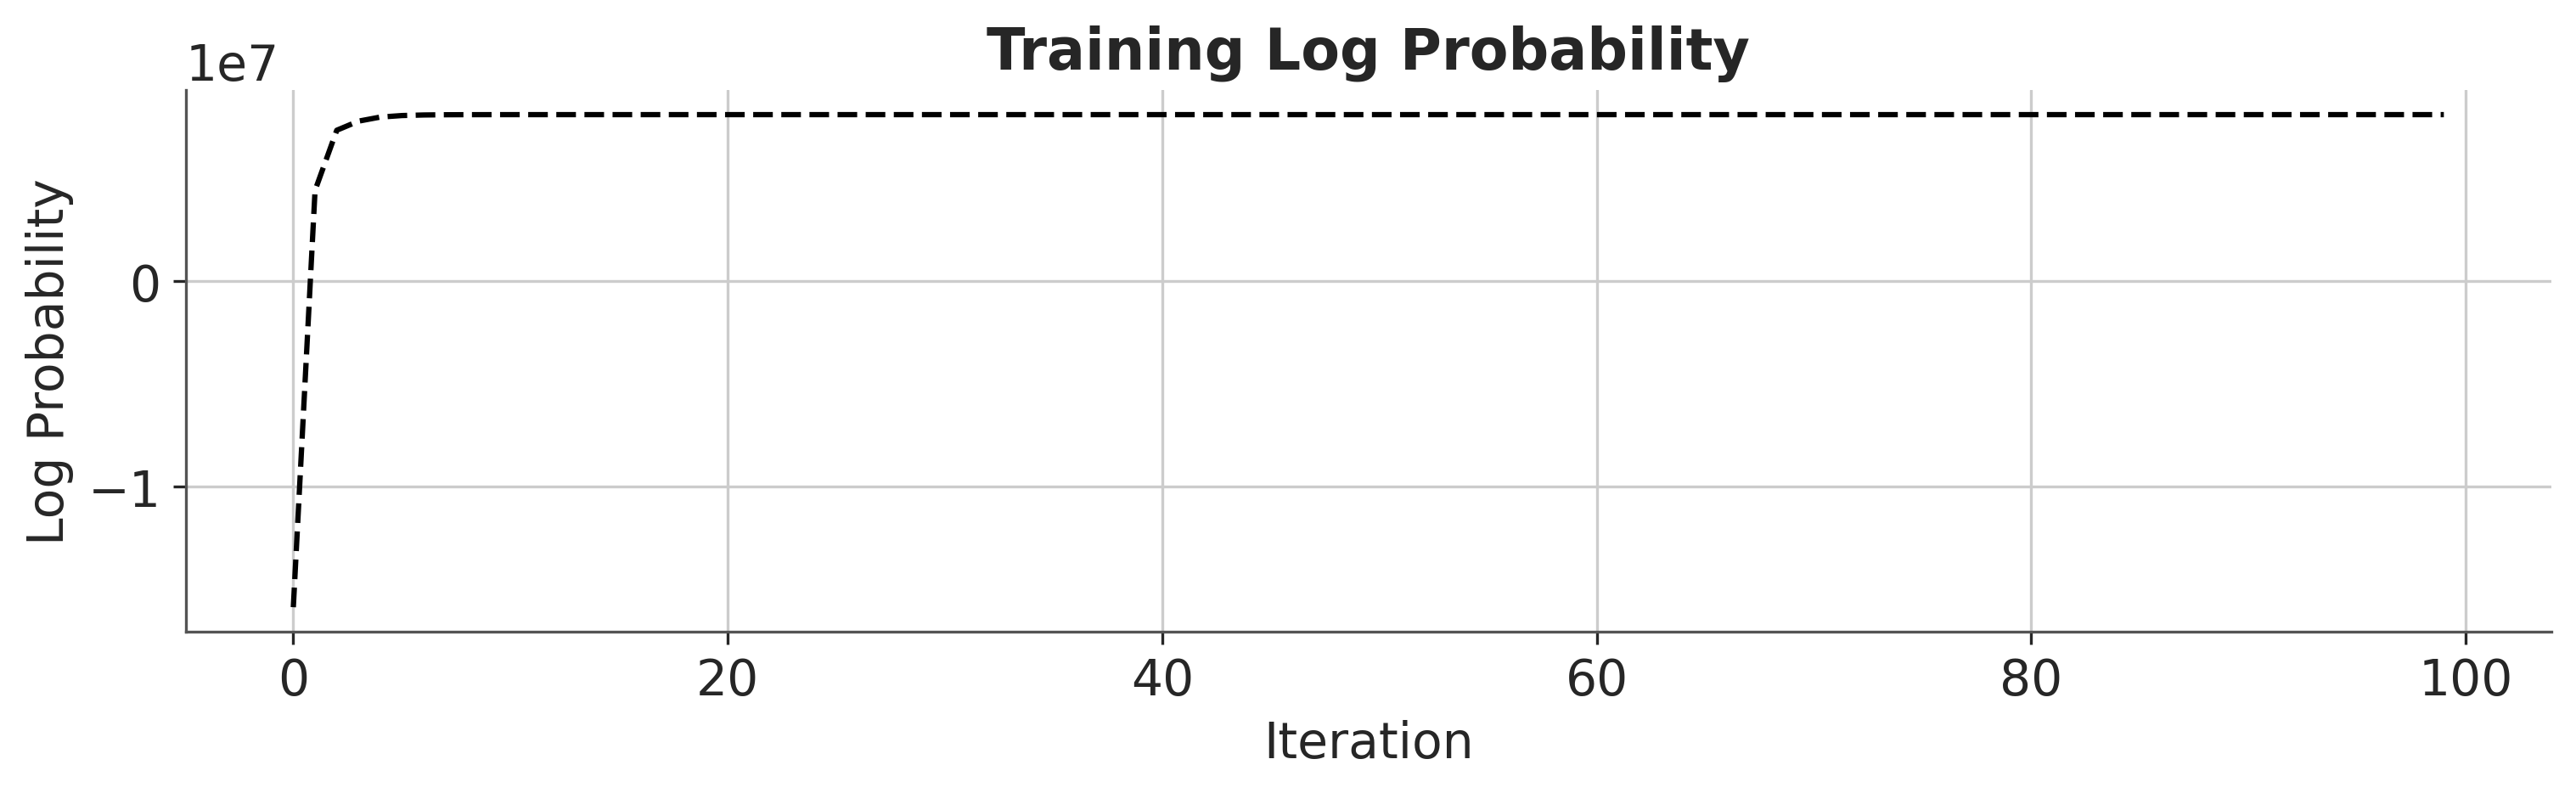

In [16]:
plt.figure(figsize=(10, 3))
plt.plot(lps, "k--")
plt.xlabel("Iteration")
plt.ylabel("Log Probability")
plt.title("Training Log Probability")
plt.show()

In [19]:
# pickle the params\
# with open("global_init_params_2_states.pkl", "wb") as f:
#     pickle.dump(params, f)

In [22]:
# with open("hmm_caches/global_init_params_2_states.pkl", "rb") as f:
#     params = pickle.load(f)

In [25]:
params.transitions

ParamsStandardHMMTransitions(transition_matrix=Array([[0.994412  , 0.00558809],
       [0.00864948, 0.9913505 ]], dtype=float32))

In [26]:
params.emissions

ParamsGaussianHMMEmissions(means=Array([[0.08588442, 0.3640902 ],
       [0.7501884 , 0.24068972]], dtype=float32), covs=Array([[[ 0.00285924,  0.00082319],
        [ 0.00082319,  0.06506077]],

       [[ 0.07698141, -0.00261457],
        [-0.00261457,  0.05046049]]], dtype=float32))

In [27]:
params.initial

ParamsStandardHMMInitialState(probs=Array([0.96720254, 0.03279735], dtype=float32))